In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Langsmith now uses UUID v7",
    category=UserWarning
)

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from typing import Annotated, List, Literal, Union
from langchain_core.tools import tool

@tool
def calculator(
    operation: Literal["add", "subtract", "multiply", "divide"],
    a: Union[int, float],
    b: Union[int, float]
) -> Union[int, float]:
    """Define a two input character tool that returns precise answers.

    Arg:
        operation (str): The operation to perfrom('add', 'subtract', 'multiply', 'divide')
        a (float or int): The first number
        b (float or int): The second number

        Returns:
            result (float or int): the result of the operation
        Example:
            Divide: result = a/b
            Subtract: result = a-b
    
    """
    if operation == "divide" and b==0:
        return {"error": "Division by zero is not allowed."}
    
    match operation:
        case "add":
            return a+b
        case "subtract":
            return a-b
        case "divide":
            return a/b
        case "multiply":
            return a*b
        case _:
            return "Unknown Operation"

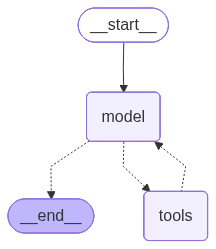

In [4]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState

SYSTEM_PROMPT = """
You are a helpful arithmatic assistance who is an expert at using a calculator. Return all text as plain text without Markdown math delimeters.
"""

model = init_chat_model(model="openai:gpt-4.1-mini", temperature=0.0)
tools = [calculator]

agent = create_agent(
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=AgentState # this is default too
). with_config({"recursion_limit": 20}) #recursion_limit limits the number of steps the agent will run

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [5]:
type(agent)

langgraph.graph.state.CompiledStateGraph

In [6]:
from langchain_core.messages import convert_to_messages
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What is 3.14 mutliplied by 4.5",
        }
    ],
})

openai_formatted_history = [
    {"role": msg.type, "content": msg.content} 
    for msg in result["messages"]
]

# 2. Or print the whole thread to see the agent's full thought process
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")


human: What is 3.14 mutliplied by 4.5
ai: 
tool: 14.13
ai: 3.14 multiplied by 4.5 is 14.13.


### Custom State

In [7]:
from langchain.agents import AgentState
from typing import Annotated

def reduce_list(left: list|None, right: list|None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right=[]
    return left + right

class CalcState(AgentState):
    """Graph State"""
    ops = Annotated[list[str], reduce_list]

In [8]:
from langgraph.prebuilt import InjectedState
from langchain_core.tools import InjectedToolCallId
from langgraph.types import Command
from langchain_core.messages import ToolMessage

@tool
def calculator_wstate(
    operation: Literal["add", "subtract", "multiply", "divide"],
    a: Union[int, float],
    b: Union[int, float],
    state: Annotated[CalcState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId]  # <--- Changed '=' to ':'
) -> Union[int, float]:
    """Define a two input character tool that returns precise answers.

    Arg:
        operation (str): The operation to perform ('add', 'subtract', 'multiply', 'divide')
        a (float or int): The first number
        b (float or int): The second number

        Returns:
            result (float or int): the result of the operation
        Example:
            Divide: result = a/b
            Subtract: result = a-b
    
    """
    if operation == "divide" and b == 0:
        return {"error": "Division by zero is not allowed."}
    
    match operation:
        case "add":
            result = a + b  # <--- Changed '-' to '+'
        case "subtract":
            result = a - b
        case "divide":
            result = a / b
        case "multiply":
            result = a * b
        case _:
            result = "Unknown Operation"  # <--- Changed 'retresult' to 'result'
        
    ops = [f"({operation}, {a}, {b}),"]
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ]
        }
    )


In [9]:
SYSTEM_PROMPT = """
You are a helpful arithmetic assistant who is an expert at using a calculator. 
Return all text as plain text without Markdown math delimiters.
"""

model = init_chat_model(model="openai:gpt-4o-mini", temperature=0.0)
tools = [calculator_wstate]

agent = create_agent(
    model=model,
    tools = tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=CalcState
).with_config({"recursion_limit": 20})

In [10]:
result2 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 3.1 * 4.2?",
            }
        ],
    }
)

for msg in result2["messages"]:
    print(f"{msg.type} : {msg.content}")

human : What is 3.1 * 4.2?
ai : 
tool : 13.020000000000001
ai : 3.1 multiplied by 4.2 is 13.02.


In [12]:
from IPython.core.display import JSON
JSON(result2)

<IPython.core.display.JSON object>

In [23]:
import sys

# Clear the cached reference in memory
if 'utils' in sys.modules:
    del sys.modules['utils']

# Import from the new local utils.py file
from utils import format_messages

result3 = agent.invoke(
    {
        "messages": [
            {
            "role": "user",
            "content": "What is 3.1*4.2 + 5.5 *6.5?",
            }
        ]
    }
)

format_messages(result3["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1*4.2 + 5.5 *6.5?                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_HSuE2G7HA6HeBnE4wl3AVQww                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5.5,                                                                                                     │
│   "b": 6.5                                                                                                      │
│ }                                                                                                               │
│    ID: call_HnoXpgsV18TCpbgPbCFM4uHx                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 35.75                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 13.020000000000001,                                                                                      │
│   "b": 35.75                                                                                                    │
│ }                                                                                                               │
│    ID: call_n83zvLjlpfsdRBv7rKUK6H2k                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 48.77                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The result of 3.1 * 4.2 + 5.5 * 6.5 is 48.77.                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [24]:
result4 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Create an example of your own?",
            }
        ],
    }
)

format_messages(result4["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Create an example of your own?                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Sure! Let's say we want to perform the following arithmetic operations:                                         │
│                                                                                                                 │
│ 1. Add 15 and 27                                                                                                │
│ 2. Subtract 50 from 100                                                                                         │
│ 3. Multiply 8 by 12                                                                                             │
│ 4. Divide 144 by 12                                                                                             │
│                                                                                                                 │
│ I will calculate these operations now.                                                                          │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 15,                                                                                                      │
│   "b": 27                                                                                                       │
│ }                                                                                                               │
│    ID: call_BoYLbrLtc3gOw0tUIPoF0iCG                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "subtract",                                                                                      │
│   "a": 100,                                                                                                     │
│   "b": 50                                                                                                       │
│ }                                                                                                               │
│    ID: call_EUPr15YREaHf6wMoSWf2ZSZT                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 8,                                                                                                       │
│   "b": 12                                                                                                       │
│ }                                                                                                               │
│    ID: call_OSnLOqz5YwRytjZwmFXs2mKd                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                            

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 42                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 50                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 96                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 12.0                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here are the results of the arithmetic operations:                                                              │
│                                                                                                                 │
│ 1. 15 + 27 = 42                                                                                                 │
│ 2. 100 - 50 = 50                                                                                                │
│ 3. 8 * 12 = 96                                                                                                  │
│ 4. 144 / 12 = 12.0                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯